In [4]:
!pip install geopandas

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------- ----------------------------- 5.8/22.9 MB 27.1 MB/s eta 0:00:01
   -------------------- ------------------- 11.5/22.9 MB 26.7 MB/s eta 0:00:01
   ---------------------------- ----------- 16.5/22.9 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------  22.8/22.9 MB 27.7 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 25.9 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------  6.3/6.3 MB 29.7 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 27.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 31.1 MB/s  0:00:00

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


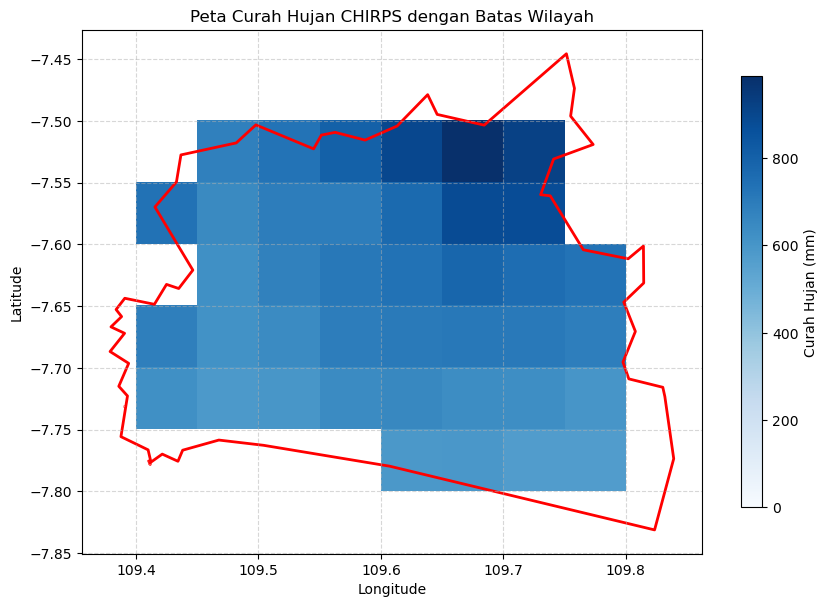

In [7]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

# 1. Buka File GeoJSON (Batas Wilayah)
file_geojson = "D:\Kuliah Semester 7\SKRIPSI\kabupaten_kebumen.geojson"
gdf = gpd.read_file(file_geojson)

# 2. Buka File TIFF CHIRPS
file_tiff = "D:\Kuliah Semester 7\SKRIPSI\CHIRPS_2022-2025\chirps_global_3month_data_20250501_20250731_Indonesia+Jawa Tengah+Kebumen.tiff"
with rasterio.open(file_tiff) as dataset:
    curah_hujan = dataset.read(1)
    nodata_value = dataset.nodata
    
    # Masking nilai -9999 menjadi NaN
    curah_hujan = np.where(curah_hujan == nodata_value, np.nan, curah_hujan)
    
    # KUNCI 1: Pastikan Sistem Koordinat (CRS) GeoJSON & CHIRPS Sama!
    if gdf.crs != dataset.crs:
        gdf = gdf.to_crs(dataset.crs)
        print("CRS GeoJSON berhasil disamakan dengan CRS CHIRPS.")
        
    # KUNCI 2: Ambil batas spasial peta untuk menyelaraskan piksel dengan koordinat bumi
    batas_spasial = [dataset.bounds.left, dataset.bounds.right, 
                     dataset.bounds.bottom, dataset.bounds.top]

# 3. Visualisasi Gabungan (Overlay)
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Raster CHIRPS (Gunakan parameter 'extent' agar posisinya mengikuti koordinat lintang/bujur)
img = ax.imshow(curah_hujan, cmap='Blues', vmin=0, extent=batas_spasial)

# Plot Garis Tepi GeoJSON
# facecolor="none"   -> Agar tengahnya bolong (transparan) dan tidak menutupi warna hujan
# edgecolor='red'    -> Warna garis tepian (bisa diganti 'black', dll)
gdf.plot(ax=ax, facecolor="none", edgecolor='red', linewidth=2)

plt.colorbar(img, ax=ax, label='Curah Hujan (mm)', shrink=0.7)
plt.title('Peta Curah Hujan CHIRPS dengan Batas Wilayah')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()